##Q1111111111111111111111111111111111111111

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")

print(df.head())


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [3]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


In [4]:
print(df.describe())


       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [5]:

target = "tip"
print("Target Variable:", target)

Target Variable: tip


In [6]:
print(df.tail())


     total_bill   tip     sex smoker   day    time  size
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2


##222222222222222222222222222

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

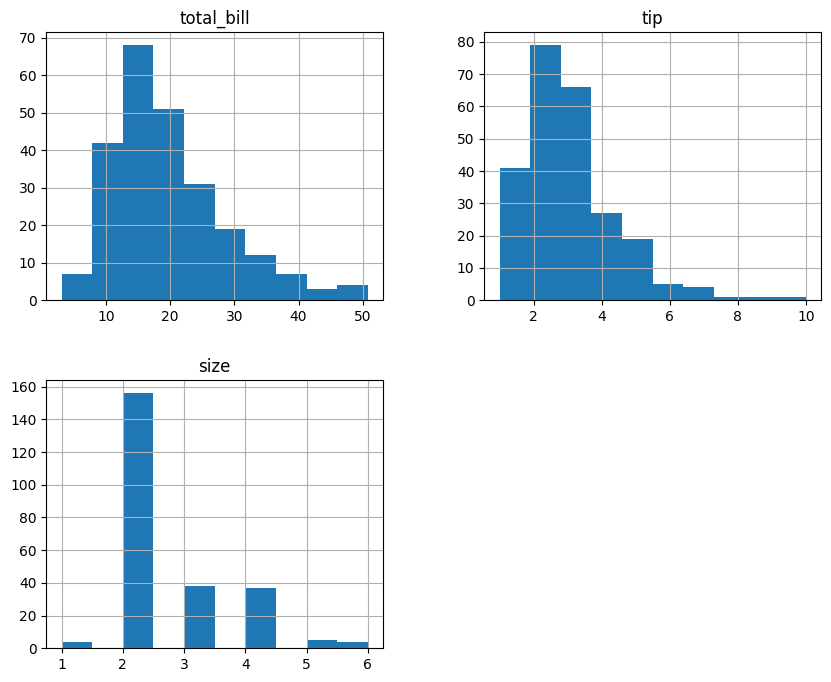

In [8]:
df.hist(figsize=(10,8))
plt.show()

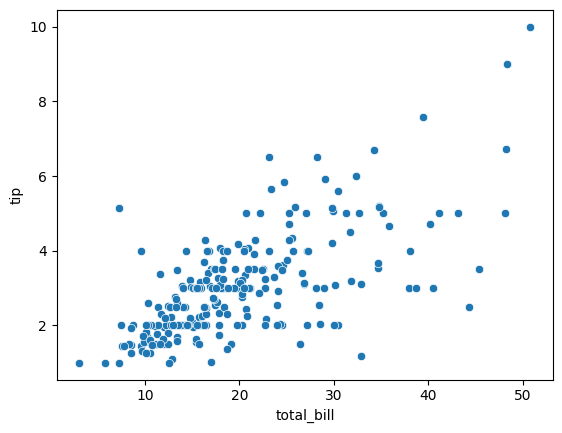

In [9]:
sns.scatterplot(x="total_bill", y="tip", data=df)
plt.show()

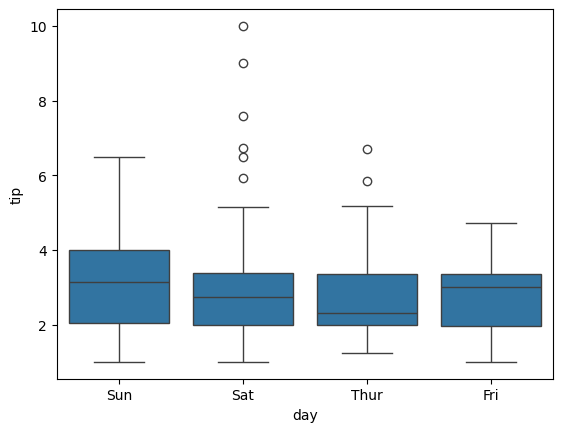

In [10]:
sns.boxplot(x="day", y="tip", data=df)
plt.show()

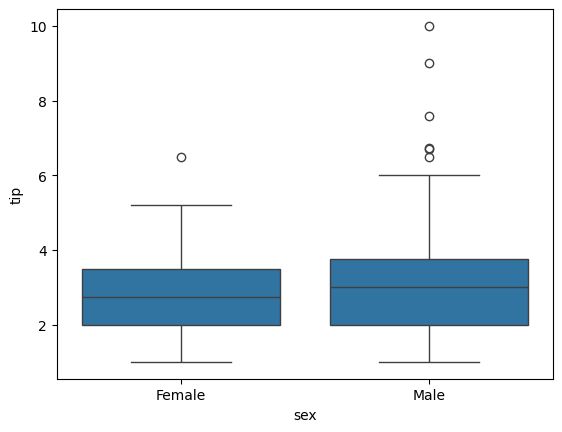

In [11]:
sns.boxplot(x="sex", y="tip", data=df)
plt.show()

In [12]:
print(df.corr(numeric_only=True))

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


###3333333333333333333

In [19]:
print(df.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [20]:
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3 - Q1

In [15]:
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [16]:
print("Before:")
print(df["total_bill"].describe())

Before:
count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


In [17]:
df_clean = df[(df["total_bill"] >= lower) & (df["total_bill"] <= upper)]


In [18]:
print("After:")
print(df_clean["total_bill"].describe())

After:
count    235.000000
mean      18.798681
std        7.438468
min        3.070000
25%       13.215000
50%       17.460000
75%       23.135000
max       40.170000
Name: total_bill, dtype: float64


##444444444444444444444

In [26]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_clean["total_bill_scaled"] = scaler.fit_transform(
    df_clean[["total_bill"]]
)



C:\Users\deeks\AppData\Local\Temp\ipykernel_23780\1594073451.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["total_bill_scaled"] = scaler.fit_transform(


In [22]:
print("Before Scaling:")
print(df_clean["total_bill"].describe())

Before Scaling:
count    235.000000
mean      18.798681
std        7.438468
min        3.070000
25%       13.215000
50%       17.460000
75%       23.135000
max       40.170000
Name: total_bill, dtype: float64


In [27]:
print("After Scaling:")
print(df_clean["total_bill_scaled"].describe())

After Scaling:
count    2.350000e+02
mean    -2.910202e-16
std      1.002134e+00
min     -2.119019e+00
25%     -7.522515e-01
50%     -1.803514e-01
75%      5.842029e-01
max      2.879213e+00
Name: total_bill_scaled, dtype: float64


##555555555555555555555555555555555

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [35]:

X = df_clean[["total_bill"]]
y = df_clean["tip"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test)


In [33]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Slope: 0.10715594602377068
Intercept: 0.8984951706373274
R2 Score: 0.38417130009161193
MSE: 1.1540471488296975


In [36]:
import numpy as np

X_vals = df_clean["total_bill"]
Y_vals = df_clean["tip"]

cov = np.cov(X_vals, Y_vals, bias=True)[0][1]
var = np.var(X_vals)

manual_slope = cov / var

print("Manual Slope:", manual_slope)
print("Library Slope:", model.coef_[0])

Manual Slope: 0.10491118865709444
Library Slope: 0.10715594602377068


In [48]:
X_full = df[["total_bill"]]
Y_full = df["tip"]
model2 = LinearRegression()
model2.fit(X_full,Y_full)
pred_full = model2.predict(X_full)
print("R2 Before:",r2_score(X_full,Y_full))
print("R2 After:",r2_score(X,Y))

R2 Before: -3.384768979249934


NameError: name 'Y' is not defined